# Description
This is an experimental Notebook, using all available transaction data

In [167]:
import pandas as pd
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import random
from ISLP.models import (ModelSpec as MS)
import statsmodels.api as sm

# Testing the weather Heterogeneity of the US states

In [168]:
cols = ["date", "st_abb", "ppt", "tavg"]
weather_df = pd.read_csv("data/Weather_data.csv", usecols=cols)

weather_df["date"] = pd.to_datetime(weather_df["date"], format='%Y%m%d')
weather_df.info

<bound method DataFrame.info of        st_abb       date     ppt    tavg
0          AL 2017-01-01  25.626   9.280
1          AL 2017-01-02  40.827  15.469
2          AL 2017-01-03  54.893  16.664
3          AL 2017-01-04   0.048  13.951
4          AL 2017-01-05   0.002   5.527
...       ...        ...     ...     ...
122683     WY 2023-12-27   0.529  -6.762
122684     WY 2023-12-28   0.013  -5.429
122685     WY 2023-12-29   0.034  -4.017
122686     WY 2023-12-30   0.035  -2.372
122687     WY 2023-12-31   0.003  -1.702

[122688 rows x 4 columns]>

In [169]:
"""df_Cfa_weather = weather_df[weather_df["st_abb"].isin(["SD", "NE", "KS", "IA", "IL", "IN", "OH", "PA", "NY", "CT", "MA", "RI"])]
df_Cfa_weather"""

'df_Cfa_weather = weather_df[weather_df["st_abb"].isin(["SD", "NE", "KS", "IA", "IL", "IN", "OH", "PA", "NY", "CT", "MA", "RI"])]\ndf_Cfa_weather'


=== Shapefile Validation ===
Shapefile columns: ['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2', 'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt', 'name_local', 'type', 'type_en', 'code_local', 'code_hasc', 'note', 'hasc_maybe', 'region', 'region_cod', 'provnum_ne', 'gadm_level', 'check_me', 'datarank', 'abbrev', 'postal', 'area_sqkm', 'sameascity', 'labelrank', 'name_len', 'mapcolor9', 'mapcolor13', 'fips', 'fips_alt', 'woe_id', 'woe_label', 'woe_name', 'latitude', 'longitude', 'sov_a3', 'adm0_a3', 'adm0_label', 'admin', 'geonunit', 'gu_a3', 'gn_id', 'gn_name', 'gns_id', 'gns_name', 'gn_level', 'gn_region', 'gn_a1_code', 'region_sub', 'sub_code', 'gns_level', 'gns_lang', 'gns_adm1', 'gns_region', 'min_label', 'max_label', 'min_zoom', 'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_en', 'name_es', 'name_fr', 'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it', 'name_ja', 'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru', 'name_sv', 'name_tr', 'name_vi',

e:\pinokio\bin\miniconda\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)



=== Legend Creation Validation ===
Legend entry: BSk -> #3182bd -> Cold semi-arid
Legend entry: BWh -> #deebf7 -> Hot desert
Legend entry: BWk -> #9ecae1 -> Cold desert
Legend entry: Cfa -> #2171b5 -> Humid subtropical
Legend entry: Dfa -> #54278f -> Hot-summer humid continental
Legend entry: Dfb -> #756bb1 -> Warm-summer humid continental


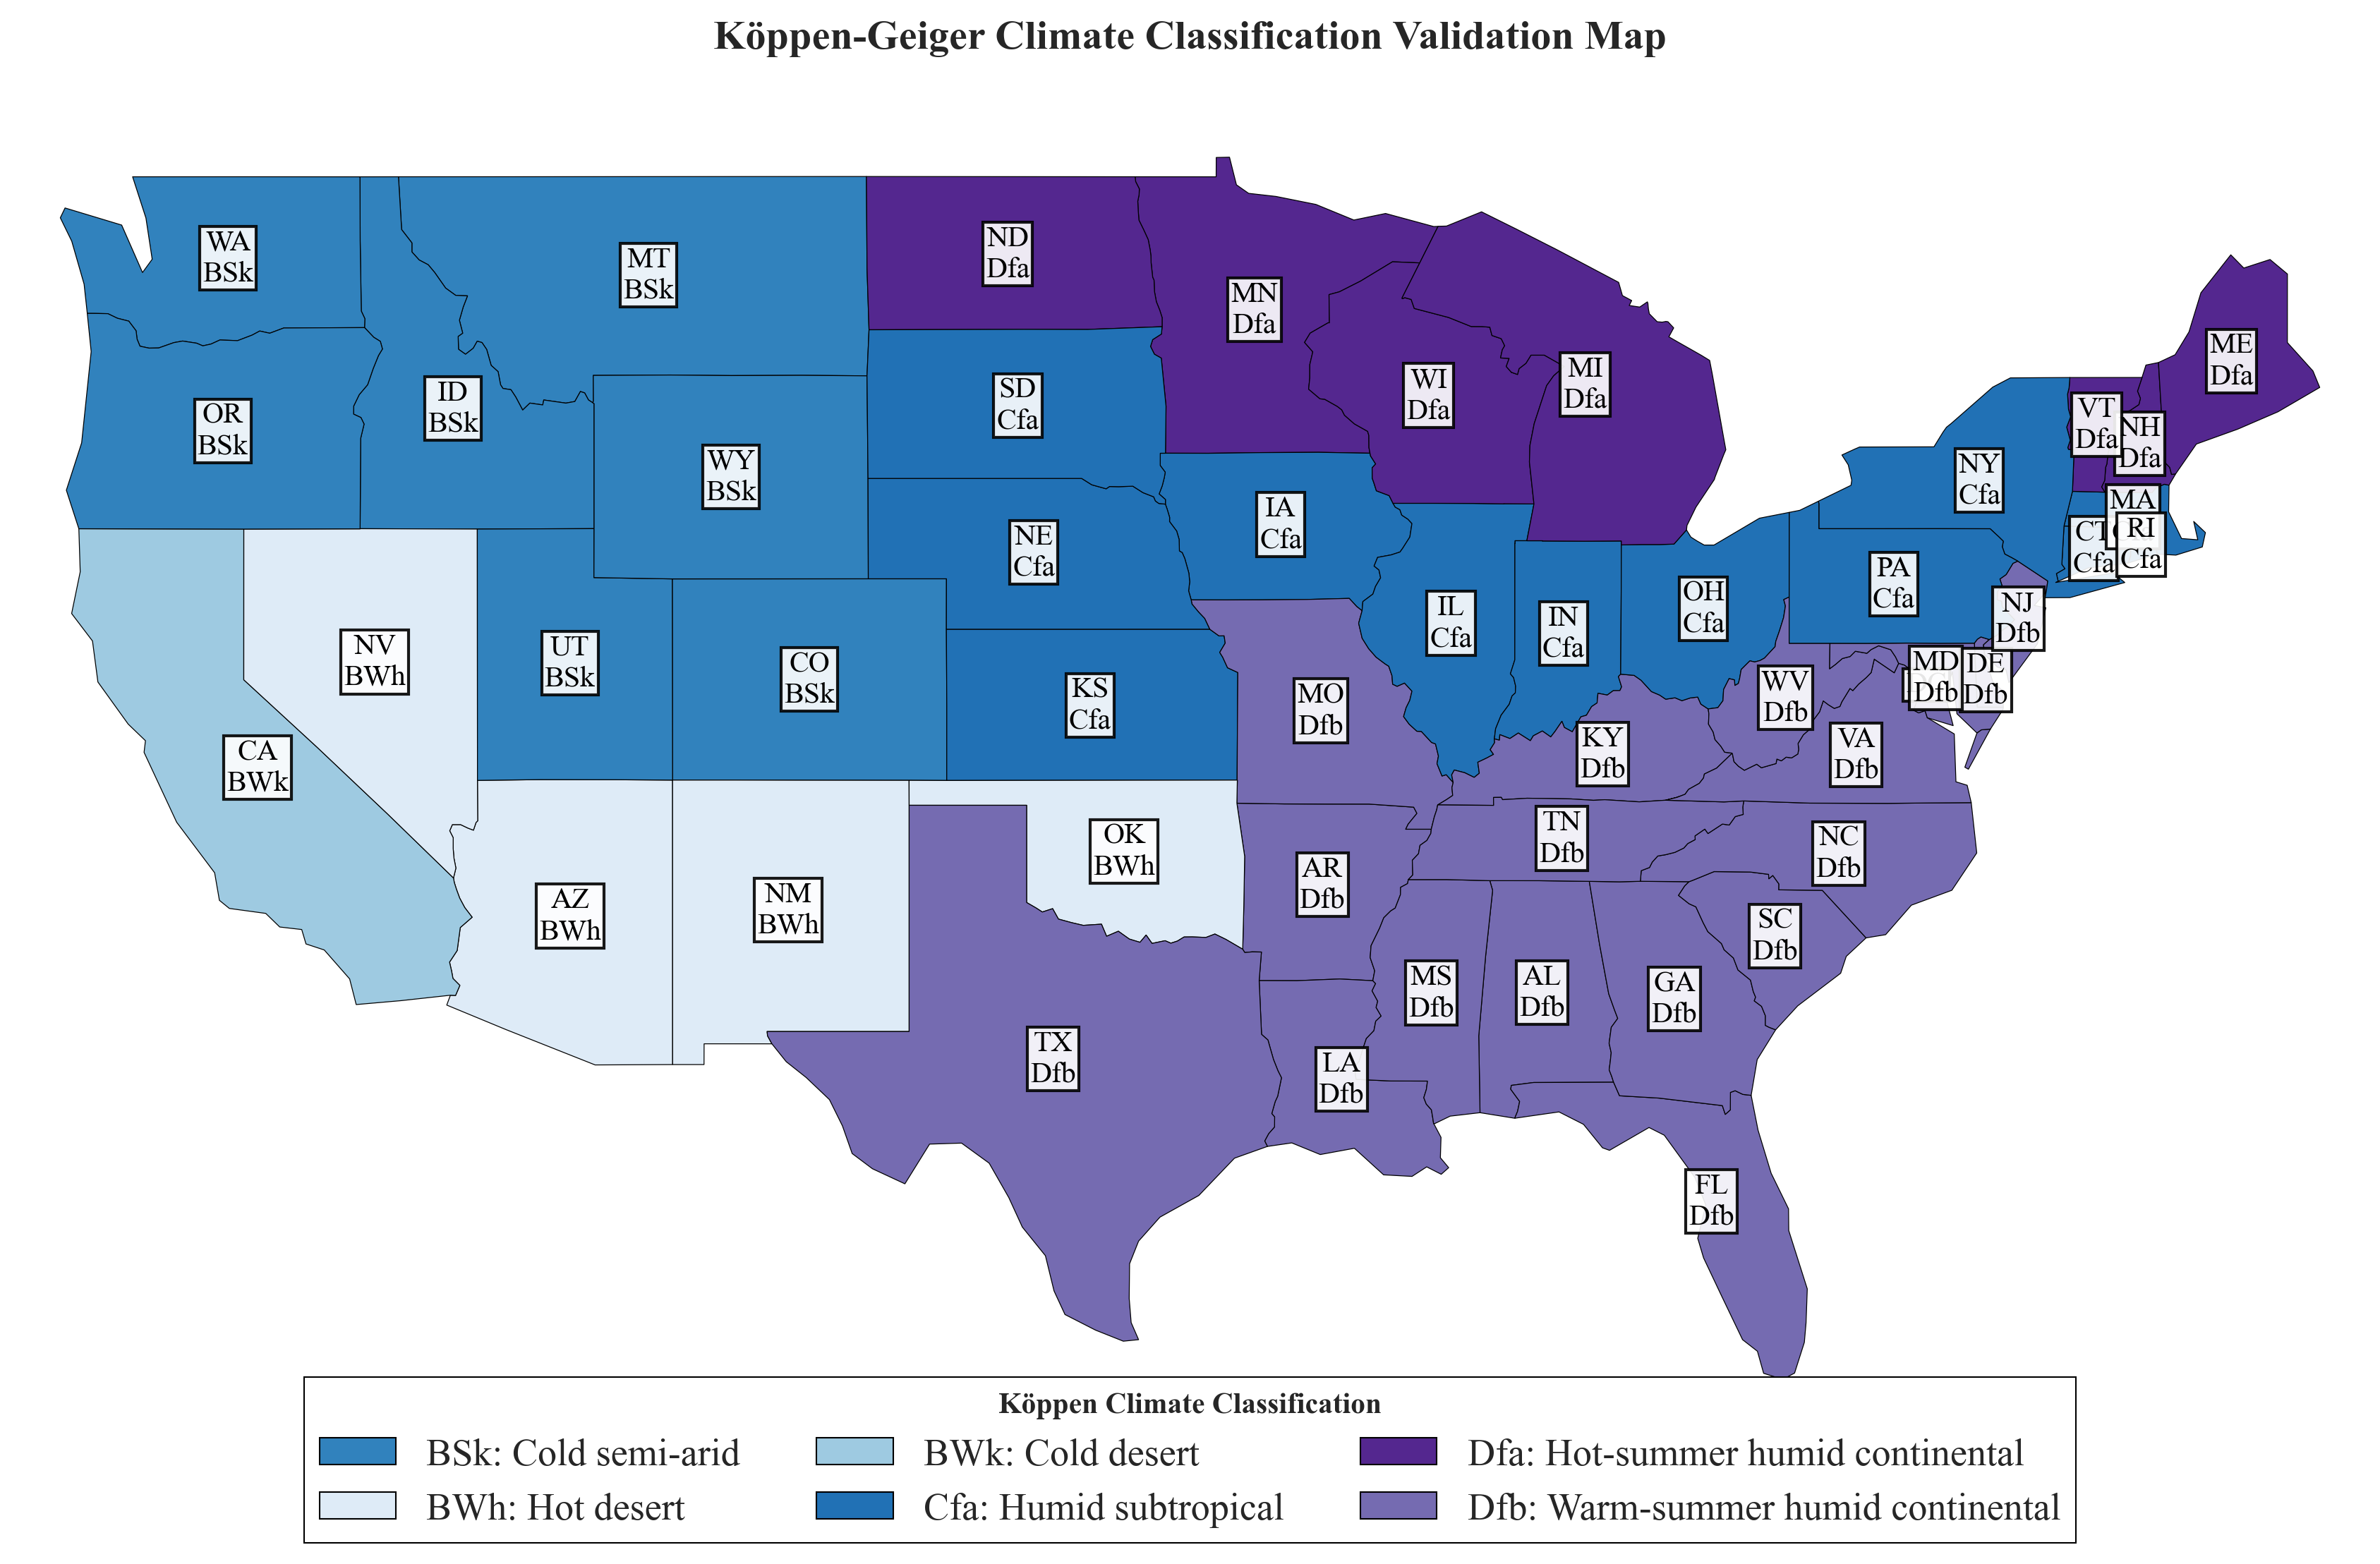

In [197]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

# Set academic plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 10,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

climate_df = pd.read_csv("data/koeppen_states")

"""# VALIDATION STEP 1: Check the climate data structure
print("=== Climate Data Validation ===")
print("Climate data columns:", climate_df.columns.tolist())
print("Sample climate data:")
print(climate_df.head())
print("\nUnique Köppen codes in data:", sorted(climate_df['koppen_code'].unique()))
print("\nState-Climate mapping sample:")
print(climate_df[['state_abbrev', 'koppen_code', 'climate_description']].head(10))"""

# Load US states shapefile
try:
    usa = gpd.read_file('./Map_USA/ne_110m_admin_1_states_provinces.shp')
    
    # VALIDATION STEP 2: Check shapefile structure
    print("\n=== Shapefile Validation ===")
    print("Shapefile columns:", usa.columns.tolist())
    
    # Handle postal column creation
    if 'postal' not in usa.columns:
        if 'iso_3166_2' in usa.columns:
            usa['postal'] = usa['iso_3166_2'].str.replace('US-', '')
            print("Using 'iso_3166_2' column for state codes")
        elif 'STUSPS' in usa.columns:
            usa['postal'] = usa['STUSPS']
            print("Using 'STUSPS' column for state codes")
        else:
            print("Warning: Could not find suitable state code column")
    
    print("Sample state codes from shapefile:", usa['postal'].head(10).tolist())
    
except Exception as e:
    print(f"Error loading shapefile: {e}")

# Remove Alaska and Hawaii for contiguous US map
usa_continental = usa[~usa['postal'].isin(['AK', 'HI'])]
usa_continental['state'] = usa_continental['postal']

print(f"\nTotal continental states: {len(usa_continental)}")
print("Continental state codes:", sorted(usa_continental['state'].tolist()))

"""# VALIDATION STEP 3: Check merge operation
print("\n=== Merge Validation ===")
print("States in climate data:", sorted(climate_df['state_abbrev'].unique()))
print("States in shapefile:", sorted(usa_continental['state'].unique()))"""

# Check for mismatches
climate_states = set(climate_df['state_abbrev'].unique())
shapefile_states = set(usa_continental['state'].unique())
missing_in_climate = shapefile_states - climate_states
missing_in_shapefile = climate_states - shapefile_states

if missing_in_climate:
    print(f"States in shapefile but NOT in climate data: {missing_in_climate}")
if missing_in_shapefile:
    print(f"States in climate data but NOT in shapefile: {missing_in_shapefile}")

# Merge with climate data
usa_climate = usa_continental.merge(climate_df[['state_abbrev', 'koppen_code', 'climate_description']], 
                                   left_on='state', right_on='state_abbrev', how='left')

"""# VALIDATION STEP 4: Check merge results
print(f"\nStates after merge: {len(usa_climate)}")
print(f"States with Köppen codes: {len(usa_climate.dropna(subset=['koppen_code']))}")
states_with_nan = usa_climate[usa_climate['koppen_code'].isna()]['state'].tolist()
if states_with_nan:
    print(f"States without Köppen codes: {states_with_nan}")"""

# Academic color scheme for Köppen codes - FIXED ORDER
koppen_colors = {
    # A - Tropical climates (dark blues)
    'Af': '#08306b',  # Very dark blue
    
    # B - Dry climates (light blues to medium blues)
    'BWh': '#deebf7',  # Very light blue
    'BWk': '#9ecae1',  # Light blue
    'BSk': '#3182bd',  # Medium blue
    
    # C - Temperate climates (medium blues to blue-purple)
    'Cfa': '#2171b5',  # Deep blue
    'Csa': '#6a51a3',  # Blue-purple
    'Csb': '#807dba',  # Light blue-purple
    
    # D - Continental climates (purples)
    'Dfa': '#54278f',  # Dark purple
    'Dfb': '#756bb1',  # Medium purple
    'Dfc': '#9e9ac8',  # Light purple
}

# Create figure with academic proportions
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)

# Get valid Köppen codes and SORT them properly
valid_koppen_codes = [code for code in usa_climate['koppen_code'].unique() if pd.notna(code)]
valid_koppen_codes = sorted(valid_koppen_codes)  # Ensure consistent ordering

# Plot the map with EXPLICIT color mapping
if len(valid_koppen_codes) > 0:
    # Create color list in the same order as valid_koppen_codes
    color_list = [koppen_colors[code] for code in valid_koppen_codes if code in koppen_colors]
    
    print(f"Using {len(color_list)} colors for {len(valid_koppen_codes)} codes")
    
    usa_climate.plot(column='koppen_code', 
                    categorical=True,
                    cmap=ListedColormap(color_list),
                    ax=ax,
                    legend=False,
                    edgecolor='black',
                    linewidth=0.3,
                    missing_kwds={'color': '#f7f7f7', 'edgecolor': 'black', 'linewidth': 0.3})

# Create legend with EXPLICIT ordering
legend_elements = []

# Create legend 
print("\n=== Legend Creation Validation ===")
for code in valid_koppen_codes:
    if code in koppen_colors:
        # Find description for this code
        description_row = climate_df[climate_df['koppen_code'] == code]
        if not description_row.empty:
            description = description_row['climate_description'].iloc[0]
            short_description = description.split(' - ')[0] if ' - ' in description else description
            
            legend_elements.append(
                Patch(facecolor=koppen_colors[code], 
                      edgecolor='black',
                      linewidth=0.5,
                      label=f"{code}: {short_description}")  # Include code for validation
            )
            
            print(f"Legend entry: {code} -> {koppen_colors[code]} -> {short_description}")
        else:
            print(f"WARNING: No description found for code {code}")
    else:
        print(f"WARNING: No color defined for code {code}")

# Position legend below the plot
legend = ax.legend(handles=legend_elements, 
                  ncol=3,
                  title='Köppen Climate Classification',
                  bbox_to_anchor=(0.5, -0.1),
                  loc='lower center',
                  fontsize=13,
                  title_fontsize=10,
                  frameon=True,
                  fancybox=False,
                  shadow=False,
                  framealpha=1,
                  edgecolor='black')

# Set legend frame linewidth separately
legend.get_frame().set_linewidth(0.5)

# Customize legend title
legend.get_title().set_fontweight('bold')

# Add state labels with Köppen codes for validation
for idx, row in usa_climate.iterrows():
    centroid = row.geometry.centroid
    label_text = row['state']
    if pd.notna(row['koppen_code']):
        label_text += f"\n{row['koppen_code']}"
    
    ax.text(centroid.x, centroid.y,
            label_text,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=10,
            fontweight='normal',
            color='black',
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=1))

# Academic title formatting
plt.title('Köppen-Geiger Climate Classification Validation Map', 
          fontsize=14, 
          fontweight='bold',
          pad=20)

# Remove axes and clean up
ax.set_xlim(usa_climate.total_bounds[0] - 1, usa_climate.total_bounds[2] + 1)
ax.set_ylim(usa_climate.total_bounds[1] - 1, usa_climate.total_bounds[3] + 1)
ax.axis('off')

# Adjust layout to accommodate legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

# Save validation map
plt.savefig('./Exports/koppen_climate_map_academic.png', 
           dpi=300, 
           bbox_inches='tight',
           facecolor='white',
           edgecolor='none')

plt.show()

C:\Users\Moritz\AppData\Local\Temp\ipykernel_4152\501159593.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.93])



=== Köppen Climate Zone Correlation Analysis Summary ===
Zone     Description                         States  Mean r   Range          
--------------------------------------------------------------------------------
BSk      Cold Semi-Arid Climate              9       0.920    0.826-0.984    
BWh      Hot Desert Climate                  4       0.905    0.813-0.961    
Cfa      Humid Subtropical Climate           10      0.919    0.814-0.997    
Dfa      Hot-Summer Humid Continental        7       0.909    0.815-0.995    
Dfb      Warm-Summer Humid Continental       17      0.919    0.777-0.996    

Overall mean correlation across zones: 0.914
Range of zone mean correlations: 0.905 - 0.920

Zones with all correlations ≥ 0.75: BSk, BWh, Cfa, Dfa, Dfb


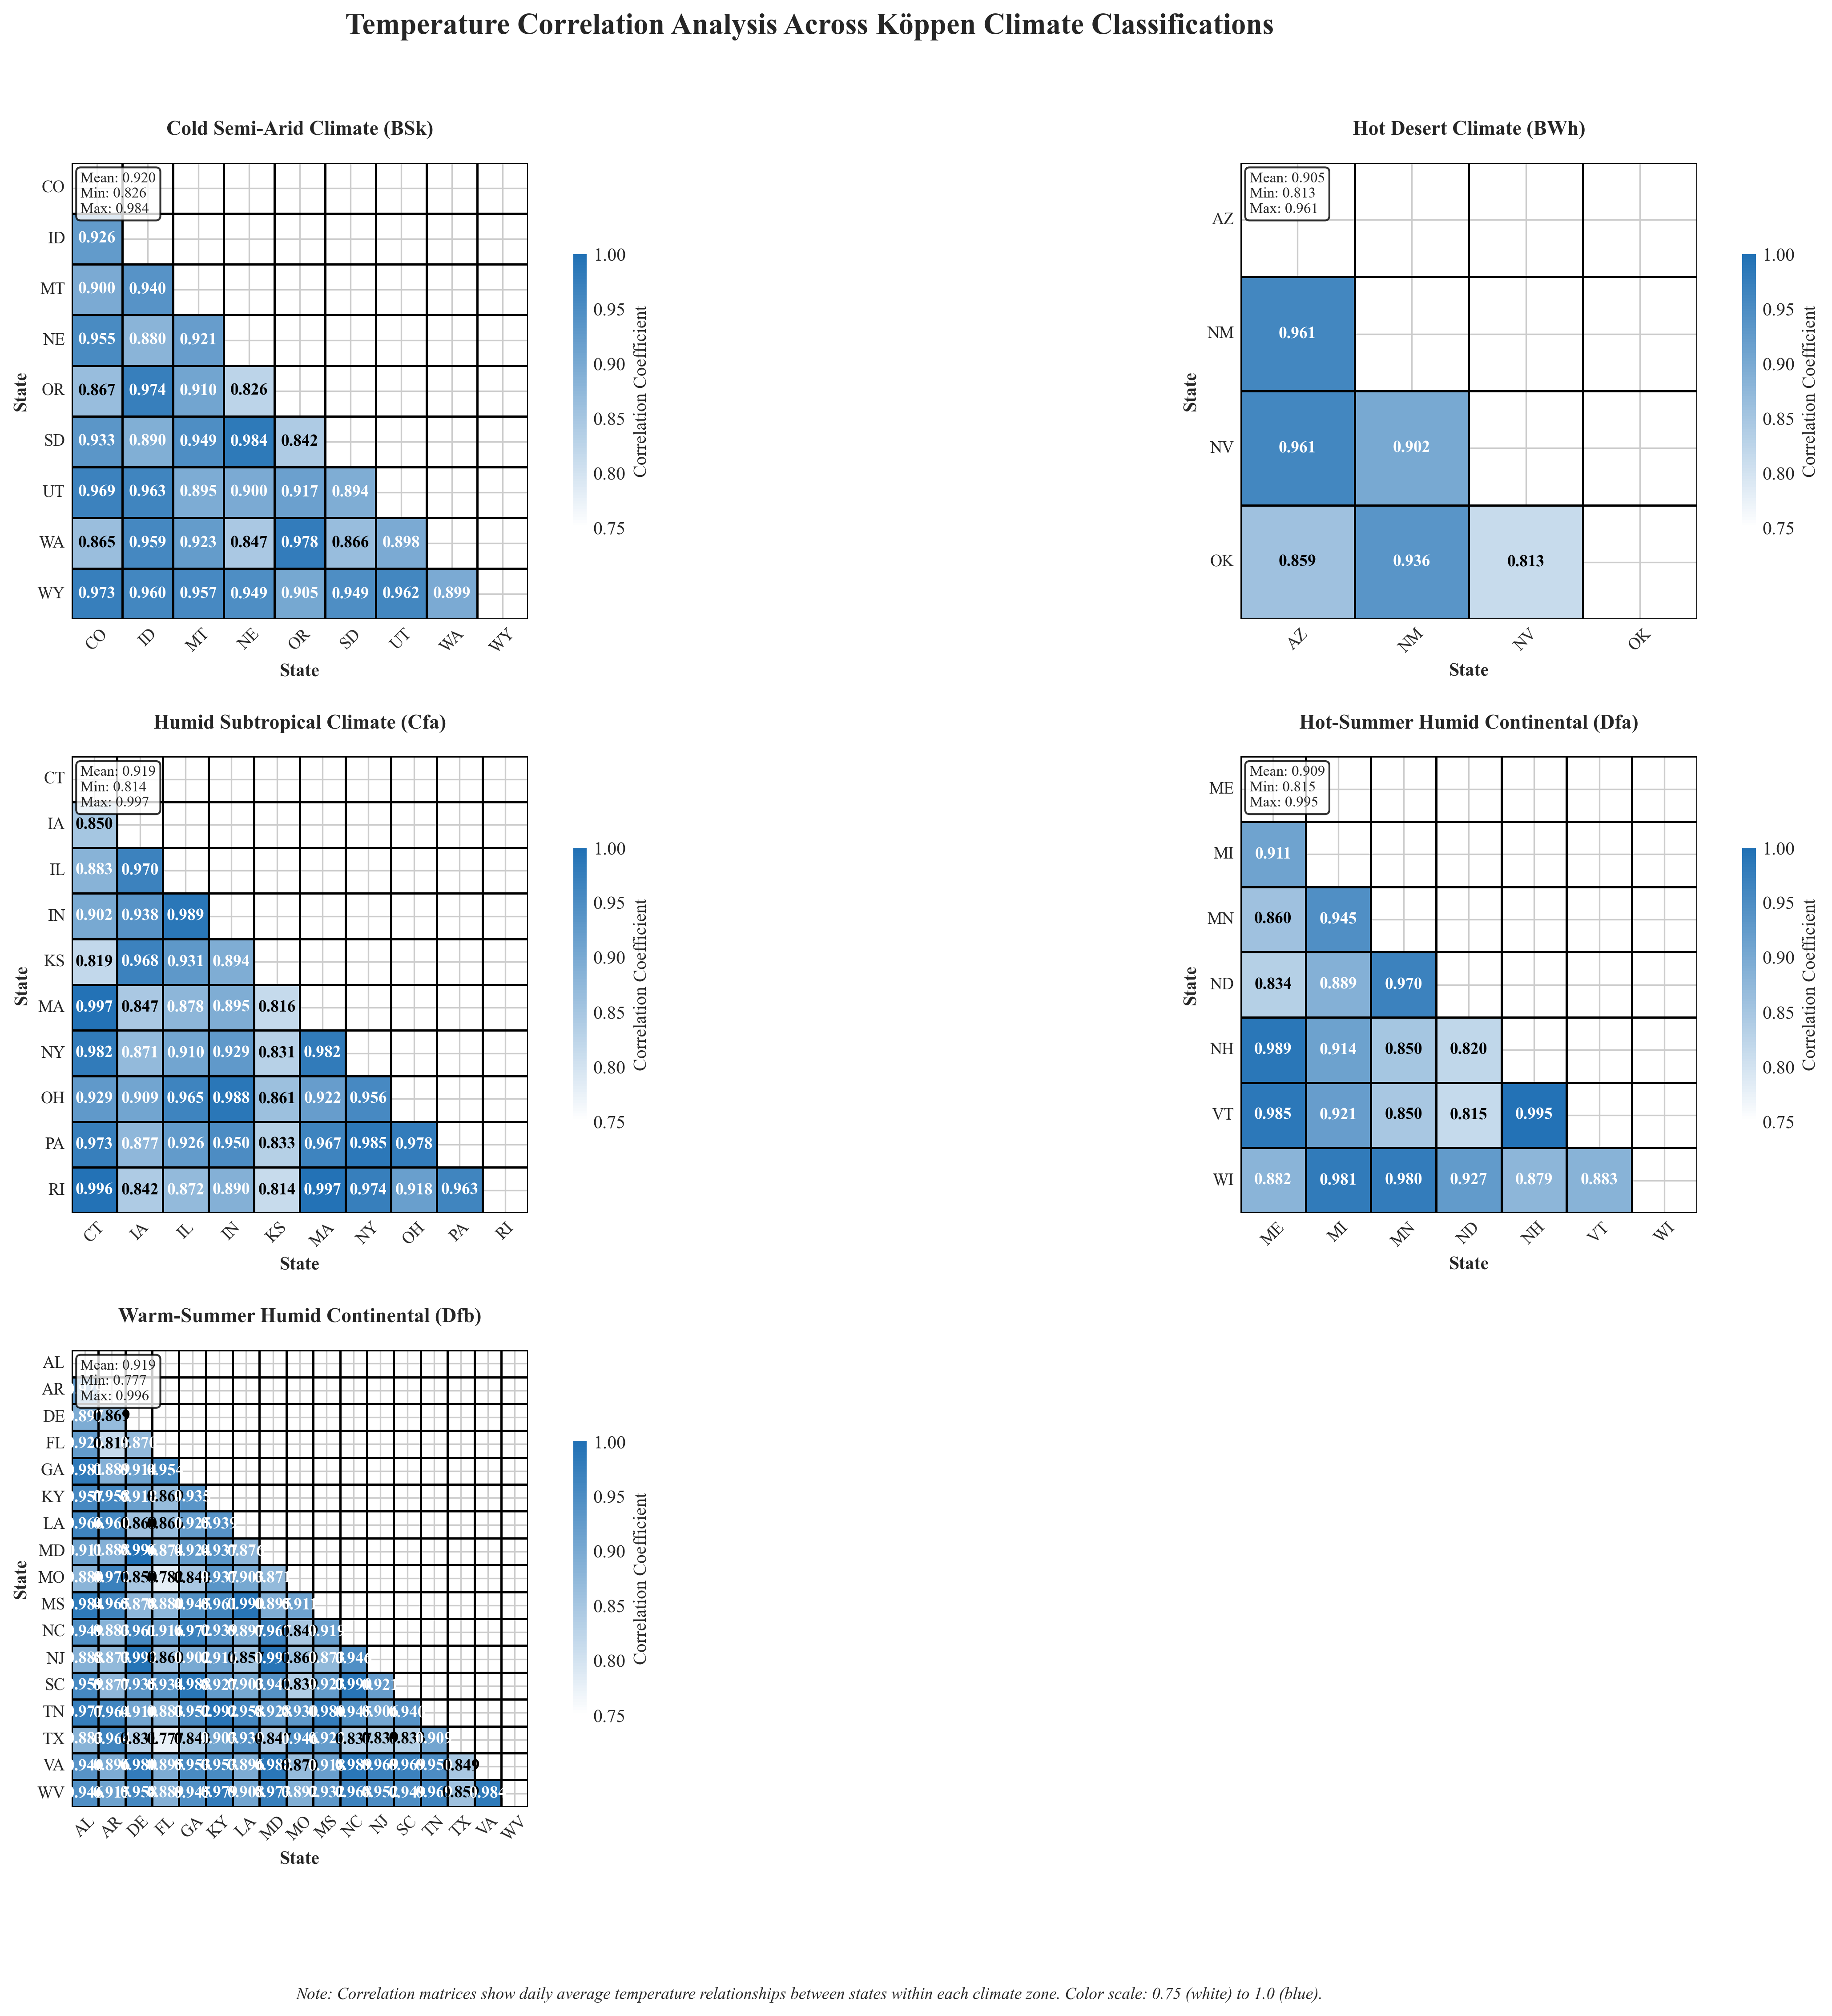

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

# Set academic plotting style to match the map
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 10,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

# Define the states belonging to each Köppen climate classification (updated from validation map)
climate_zones = {
    'BSk': ['WA', 'OR', 'MT', 'ID', 'WY', 'UT', 'CO', 'SD', 'NE'],  # Cold semi-arid
    'BWh': ['NM', 'OK', 'NV', 'AZ'],  # Hot desert
    'BWk': ['CA'],  # Cold desert
    'Cfa': ['KS', 'IA', 'IL', 'IN', 'OH', 'PA', 'NY', 'CT', 'MA', 'RI'],  # Humid subtropical
    'Dfa': ['MN', 'WI', 'MI', 'ME', 'NH', 'VT', 'ND'],  # Hot-summer humid continental
    'Dfb': ['TX', 'AR', 'MO', 'TN', 'KY', 'WV', 'VA', 'NC', 'SC', 'GA', 'AL', 'MS', 'LA', 'DE', 'MD', 'NJ', 'FL']  # Warm-summer humid continental
}

# Define zone titles with academic descriptions (updated)
zone_titles = {
    'BSk': 'Cold Semi-Arid Climate (BSk)',
    'BWh': 'Hot Desert Climate (BWh)',
    'BWk': 'Cold Desert Climate (BWk)',
    'Cfa': 'Humid Subtropical Climate (Cfa)',
    'Dfa': 'Hot-Summer Humid Continental (Dfa)',
    'Dfb': 'Warm-Summer Humid Continental (Dfb)'
}

# Function to create heatmap with conditional text colors for better readability
def create_heatmap_with_conditional_colors(corr_matrix, mask, ax, zone_title):
    """
    Create heatmap with conditional text colors based on correlation values.
    """
    # Create uniform colormap with 0.75 as minimum (white) and 1.0 as maximum (blue)
    colors = ['white', '#2171b5']  # White to deep blue for all plots
    n_bins = 100
    cmap = mcolors.LinearSegmentedColormap.from_list('correlation_scale', colors, N=n_bins)
    
    # Create heatmap without annotations first
    sns.heatmap(corr_matrix, annot=False, mask=mask,
                cmap=cmap, vmin=0.75, vmax=1.0,
                cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.6},
                square=True, ax=ax,
                linewidths=0.8, linecolor='black')
    
    # Add custom annotations with conditional colors
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            if not mask[i, j]:  # Only annotate lower triangle
                value = corr_matrix.iloc[i, j]
                # Use white text for darker backgrounds (high correlations), black for lighter
                color = 'white' if value > 0.87 else 'black'
                ax.text(j + 0.5, i + 0.5, f'{value:.3f}',
                       ha='center', va='center', color=color, 
                       fontsize=9, weight='bold')
    
    # Academic title formatting
    ax.set_title(zone_title, fontsize=11, fontweight='bold', pad=15)

# Function to create correlation matrix for a climate zone
def create_correlation_matrix(weather_df, zone_states, zone_name):
    """
    Create an individual correlation matrix for a specific climate zone.
    """
    # Filter data for states in the climate zone
    df_zone = weather_df[weather_df["st_abb"].isin(zone_states)]
    
    # Create pivot table
    pivot_df = df_zone.pivot(index='date', columns='st_abb', values='tavg')
    
    # Calculate correlation matrix
    corr_matrix = pivot_df.corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Create a figure with academic styling
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap with conditional colors
    create_heatmap_with_conditional_colors(corr_matrix, mask, ax, f'Temperature Correlation Matrix: {zone_name}')
    
    # Clean up axis labels
    ax.set_xlabel('State', fontsize=12, fontweight='bold')
    ax.set_ylabel('State', fontsize=12, fontweight='bold')
    
    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    return fig, corr_matrix

# Function to create all correlation matrices in academic style
def create_all_matrices(weather_df):
    """
    Create a comprehensive figure with all climate zone correlation matrices.
    """
    # Calculate number of valid zones
    valid_zones = []
    for zone, states in climate_zones.items():
        available_states = set(states).intersection(set(weather_df['st_abb'].unique()))
        if len(available_states) >= 2:
            valid_zones.append(zone)
    
    n_zones = len(valid_zones)
    
    # Create figure with academic proportions
    if n_zones <= 4:
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)
    else:
        fig = plt.figure(figsize=(20, 16))
        gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)
    
    # Create correlation matrix for each climate zone
    zone_stats = {}
    
    for i, zone in enumerate(valid_zones):
        states = climate_zones[zone]
        
        # Get states that actually exist in the dataset
        available_states = set(states).intersection(set(weather_df['st_abb'].unique()))
        
        # Create subplot
        if n_zones <= 4:
            ax = fig.add_subplot(gs[i // 2, i % 2])
        else:
            ax = fig.add_subplot(gs[i // 2, i % 2])
        
        # Filter data for states in the climate zone
        df_zone = weather_df[weather_df["st_abb"].isin(available_states)]
        
        # Create pivot table
        pivot_df = df_zone.pivot(index='date', columns='st_abb', values='tavg')
        
        # Calculate correlation matrix
        corr_matrix = pivot_df.corr()
        
        # Store statistics
        correlations = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
        zone_stats[zone] = {
            'mean_corr': np.mean(correlations),
            'min_corr': np.min(correlations),
            'max_corr': np.max(correlations),
            'n_states': len(available_states)
        }
        
        # Create mask for upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        # Create heatmap with conditional text colors for better readability
        create_heatmap_with_conditional_colors(corr_matrix, mask, ax, zone_titles[zone])
        
        # Clean up axis labels
        ax.set_xlabel('State', fontsize=10, fontweight='bold')
        ax.set_ylabel('State', fontsize=10, fontweight='bold')
        
        # Rotate labels for better readability
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.tick_params(axis='y', rotation=0, labelsize=9)
        
        # Add statistics text box
        stats_text = f'Mean: {zone_stats[zone]["mean_corr"]:.3f}\nMin: {zone_stats[zone]["min_corr"]:.3f}\nMax: {zone_stats[zone]["max_corr"]:.3f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='white', alpha=0.8, edgecolor='black'),
                fontsize=8)
    
    # Add overall academic title
    plt.suptitle('Temperature Correlation Analysis Across Köppen Climate Classifications', 
                fontsize=16, fontweight='bold', y=0.95)
    
    # Add methodology note
    plt.figtext(0.5, 0.02, 
               'Note: Correlation matrices show daily average temperature relationships between states within each climate zone. Color scale: 0.75 (white) to 1.0 (blue).',
               ha='center', fontsize=9, style='italic')
    
    plt.tight_layout(rect=[0, 0.04, 1, 0.93])
    
    # Save with high DPI for publication
    plt.savefig('./Exports/koppen_correlation_matrices_academic.png', 
               dpi=300, 
               bbox_inches='tight',
               facecolor='white',
               edgecolor='none')
    
    return fig, zone_stats

# Function to print academic summary
def print_correlation_summary(zone_stats):
    """
    Print academic summary of correlation analysis.
    """
    print("\n=== Köppen Climate Zone Correlation Analysis Summary ===")
    print(f"{'Zone':<8} {'Description':<35} {'States':<7} {'Mean r':<8} {'Range':<15}")
    print("-" * 80)
    
    for zone, stats in zone_stats.items():
        description = zone_titles[zone].split(' (')[0]  # Remove code from description
        range_str = f"{stats['min_corr']:.3f}-{stats['max_corr']:.3f}"
        print(f"{zone:<8} {description:<35} {stats['n_states']:<7} {stats['mean_corr']:<8.3f} {range_str:<15}")
    
    # Calculate overall statistics
    all_means = [stats['mean_corr'] for stats in zone_stats.values()]
    print(f"\nOverall mean correlation across zones: {np.mean(all_means):.3f}")
    print(f"Range of zone mean correlations: {np.min(all_means):.3f} - {np.max(all_means):.3f}")
    
    # Identify zones meeting 0.75 threshold
    high_corr_zones = [zone for zone, stats in zone_stats.items() if stats['min_corr'] >= 0.75]
    print(f"\nZones with all correlations ≥ 0.75: {', '.join(high_corr_zones) if high_corr_zones else 'None'}")

# Example usage:
fig, stats = create_all_matrices(weather_df)
print_correlation_summary(stats)
plt.show()

# For individual matrices:
# fig_cfa, corr_cfa = create_correlation_matrix(weather_df, climate_zones['Cfa'], zone_titles['Cfa'])
# plt.show()

# Lineare Regression

## Preprocessing
Because of the newly created clusters we need to do some formating steps to the df before we can do the linear regression.
The logic is similar to the one in 0_Data_Processing, we just work on the cluster level instead of state level.

In [172]:
random.seed(1234)

fashion_df = pd.read_csv("./data/fashion_meta_level.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)


groceries_df = pd.read_csv("./data/groceries_meta_level.csv")
groceries_df["Order Date"] = pd.to_datetime(groceries_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
groceries_df.drop(columns=["Unnamed: 0"], inplace=True)

In [173]:
fashion_df = fashion_df.merge(climate_df[["state_abbrev", "koppen_code", "climate_description"]], left_on="Shipping Address State", right_on="state_abbrev")
fashion_df = fashion_df.drop("state_abbrev", axis=1)
fashion_df.set_index("Order Date", inplace=True)

groceries_df = groceries_df.merge(climate_df[["state_abbrev", "koppen_code", "climate_description"]], left_on="Shipping Address State", right_on="state_abbrev")
groceries_df = groceries_df.drop("state_abbrev", axis=1)
groceries_df.set_index("Order Date", inplace=True)


weather_df = weather_df.merge(climate_df[["state_abbrev", "koppen_code", "climate_description"]], left_on="st_abb", right_on="state_abbrev")
weather_df = weather_df.drop("state_abbrev", axis=1)

weather_df

,st_abb,date,ppt,tavg,koppen_code,climate_description
0,AL,2017-01-01,25.626,9.280,Dfb,Warm-summer humid continental
1,AL,2017-01-02,40.827,15.469,Dfb,Warm-summer humid continental
2,AL,2017-01-03,54.893,16.664,Dfb,Warm-summer humid continental
3,AL,2017-01-04,0.048,13.951,Dfb,Warm-summer humid continental
4,AL,2017-01-05,0.002,5.527,Dfb,Warm-summer humid continental
...,...,...,...,...,...,...
122683,WY,2023-12-27,0.529,-6.762,BSk,Cold semi-arid
122684,WY,2023-12-28,0.013,-5.429,BSk,Cold semi-arid
122685,WY,2023-12-29,0.034,-4.017,BSk,Cold semi-arid
122686,WY,2023-12-30,0.035,-2.372,BSk,Cold semi-arid


In [174]:
# First get ratios by category
category_ratios = fashion_df.groupby(
    ["Order Date", "koppen_code", "weather_category"]
)['Revenue'].sum().reset_index()

# Calculate ratios within each date-state group
category_ratios['ratio'] = category_ratios.groupby(
    ["Order Date", "koppen_code"]
)['Revenue'].transform(lambda x: (x / x.sum()).round(4))

# Pivot to get one column per category ratio
ratio_columns = category_ratios.pivot_table(
    index=["Order Date", "koppen_code"],
    columns="weather_category",
    values="ratio",
    fill_value=0
).reset_index()

# Rename ratio columns
ratio_columns.columns = ['Order Date', 'koppen_code'] + [
    f'ratio_{col}' for col in ratio_columns.columns[2:]
]

# Get other aggregated info (revenue, survey IDs, categories)
other_info = fashion_df.groupby(["Order Date", "koppen_code"]).agg({
    "Revenue": "sum",
    "Survey ResponseID": lambda x: list(set(x)),
}).reset_index()

# Merge ratio columns with other info
Fashion_transactions_grouped = pd.merge(
    other_info,
    ratio_columns,
    on=["Order Date", "koppen_code"]
)

# Round revenue
Fashion_transactions_grouped["Revenue"] = Fashion_transactions_grouped["Revenue"].round(2)


In [175]:
# First get ratios by category
category_ratios = groceries_df.groupby(
    ["Order Date", "koppen_code", "weather_category"]
)['Revenue'].sum().reset_index()

# Calculate ratios within each date-state group
category_ratios['ratio'] = category_ratios.groupby(
    ["Order Date", "koppen_code"]
)['Revenue'].transform(lambda x: (x / x.sum()).round(4))

# Pivot to get one column per category ratio
ratio_columns = category_ratios.pivot_table(
    index=["Order Date", "koppen_code"],
    columns="weather_category",
    values="ratio",
    fill_value=0
).reset_index()

# Rename ratio columns
ratio_columns.columns = ['Order Date', 'koppen_code'] + [
    f'ratio_{col}' for col in ratio_columns.columns[2:]
]

# Get other aggregated info (revenue, survey IDs, categories)
other_info = groceries_df.groupby(["Order Date", "koppen_code"]).agg({
    "Revenue": "sum",
    "Survey ResponseID": lambda x: list(set(x)),
}).reset_index()

# Merge ratio columns with other info
groceries_transactions_grouped = pd.merge(
    other_info,
    ratio_columns,
    on=["Order Date", "koppen_code"]
)

# Round revenue
groceries_transactions_grouped["Revenue"] = groceries_transactions_grouped["Revenue"].round(2)


### Joining Df with weather information

In [176]:
clusters = fashion_df['koppen_code'].unique()

date_range = pd.date_range(
    start="1/1/2017",
    end="31/12/2023",
    freq='D'
)

date_state_combinations = pd.MultiIndex.from_product(
    [date_range, clusters],
    names=['Order Date', 'koppen_code']
)
full_index_df = pd.DataFrame(index=date_state_combinations).reset_index()

In [177]:


groceries_combined = pd.merge(
    left=full_index_df, 
    right=groceries_transactions_grouped,
    how='left',
    left_on=['koppen_code', 'Order Date'],
    right_on=['koppen_code', 'Order Date'],
)

groceries_combined_final = pd.merge(
    left= groceries_combined, 
    right= weather_df,
    how='left',
    left_on=['koppen_code', 'Order Date'],
    right_on=['koppen_code', 'date'],
)

groceries_combined_final = groceries_combined_final.drop(columns=["date"])

groceries_combined_final["Revenue"] = groceries_combined_final['Revenue'].fillna(0)

groceries_combined_final["Survey ResponseID"] = groceries_combined_final["Survey ResponseID"].fillna("")

groceries_combined_final  = groceries_combined_final[(groceries_combined_final['Order Date'] < '2023-03-21')]

In [178]:


fashion_combined = pd.merge(
    left=full_index_df, 
    right=Fashion_transactions_grouped,
    how='left',
    left_on=['koppen_code', 'Order Date'],
    right_on=['koppen_code', 'Order Date'],
)

fashion_combined_final = pd.merge(
    left= fashion_combined, 
    right= weather_df,
    how='left',
    left_on=['koppen_code', 'Order Date'],
    right_on=['koppen_code', 'date'],
)

fashion_combined_final = fashion_combined_final.drop(columns=["date"])

fashion_combined_final["Revenue"] = fashion_combined_final['Revenue'].fillna(0)

fashion_combined_final["Survey ResponseID"] = fashion_combined_final["Survey ResponseID"].fillna("")

fashion_combined_final  = fashion_combined_final[(fashion_combined_final['Order Date'] < '2023-03-21')]

## Calculating coeffients

In [179]:
groceries_combined_final

,Order Date,koppen_code,Revenue,Survey ResponseID,ratio_alcoholic_beverages,ratio_baby_products,ratio_baked_goods,ratio_breakfast_cereal,ratio_cold_weather,ratio_fresh_perishable,ratio_general_grocery,ratio_hot_weather,ratio_shelf_stable_pantry,ratio_snacks_confectionery,ratio_specialty_health,st_abb,ppt,tavg,climate_description
0,2017-01-01,Dfb,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AL,25.626,9.280,Warm-summer humid continental
1,2017-01-01,Dfb,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AR,1.999,7.548,Warm-summer humid continental
2,2017-01-01,Dfb,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE,0.000,2.684,Warm-summer humid continental
3,2017-01-01,Dfb,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FL,5.548,13.432,Warm-summer humid continental
4,2017-01-01,Dfb,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GA,9.973,6.663,Warm-summer humid continental
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108955,2023-03-20,Dfa,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ND,0.013,-9.581,Hot-summer humid continental
108956,2023-03-20,Dfa,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NH,0.082,-5.289,Hot-summer humid continental
108957,2023-03-20,Dfa,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VT,0.110,-6.537,Hot-summer humid continental
108958,2023-03-20,Dfa,0.0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WI,0.000,-4.168,Hot-summer humid continental


In [189]:
def linear_reg_staates(data, var1, var2): 
    """ 
        var1: Is the first variable for the dependent variable of the linear regression
        var2: Is the second variable for the dependent variable of the linear regression
    """
    col = ["State", "Param_1", "P_value1", "Param_2", "P_value2", "R_sqrt"]
    results_lin_reg = pd.DataFrame(columns=col)
    
    cluster_list = data["koppen_code"].unique()
    

    for cluster in cluster_list: 
        df_one_state_filter = data["koppen_code"] == cluster
        df_one_state = data[df_one_state_filter].copy()


        # 365 days lagged temp column
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

        # 365 days lagged rain column
        df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
        df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

        # first order diff Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff
        df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

        # Lag first order diff Revenue 
        df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

        # Lag revenue by 1 day
        df_one_state.loc[:, "Revenue_lagged"] = df_one_state["Revenue"].shift(-1)

        # Because of the one day shift we create a missing entry for the last day in or DF -> we fill this with 0
        df_one_state = df_one_state.fillna(0)

        # Calc SMA7 
        df_one_state.loc[:, "SMA7_ratio_hot"] = df_one_state["ratio_hot_weather"].rolling(7).mean().round(2)

        df_one_state.loc[:, "SMA7_ratio_cold"] = df_one_state["ratio_cold_weather"].rolling(7).mean().round(2)


        df_one_state.loc[:, "SMA7_ratio_cold_lagged"] = df_one_state["SMA7_ratio_cold"].shift(-1)
        df_one_state.loc[:, "SMA7_ratio_hot_lagged"] = df_one_state["SMA7_ratio_hot"].shift(-1)

        # Remove additional days for temp calculations
        df_one_state = df_one_state.iloc[365:, :]

        # Create linear time count 
        df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))
        df_one_state = df_one_state.fillna(0).infer_objects()

        x = MS(["tavg", "ppt"]).fit_transform(df_one_state)
        y = np.log(df_one_state[var1] * df_one_state[var2] + 1)
        model = sm.OLS(y, x)
        results = model.fit()

        #print(results.summary())

        next_idx = len(results_lin_reg)
        results_lin_reg.loc[next_idx] = [cluster, (results.params.iloc[1] * 100).round(3), results.pvalues.iloc[1].round(3), 
                        (results.params.iloc[2] * 100).round(3), results.pvalues.iloc[2].round(5), results.rsquared.round(3)]
        
        # Param 1 = tavg
        # Param 2 = ppt

    return results_lin_reg

In [190]:
fashion_hot_weather_rev = linear_reg_staates(fashion_combined_final, "SMA7_ratio_hot_lagged", "Revenue_lagged")
fashion_cold_weather_rev = linear_reg_staates(fashion_combined_final, "SMA7_ratio_cold_lagged", "Revenue_lagged")


groceries_hot_weather_rev = linear_reg_staates(groceries_combined_final, "SMA7_ratio_hot_lagged", "Revenue_lagged")
groceries_cold_weather_rev = linear_reg_staates(groceries_combined_final, "SMA7_ratio_cold_lagged", "Revenue_lagged")

In [191]:
print(fashion_hot_weather_rev)

  State  Param_1  P_value1  Param_2  P_value2  R_sqrt
0   Dfb    4.349       0.0   -0.015   0.91401   0.038
1   Cfa    4.474       0.0   -0.709   0.00027   0.057
2   BWh    1.180       0.0   -0.033   0.94225   0.006
3   BSk    2.578       0.0   -1.897   0.00003   0.026
4   Dfa    3.247       0.0   -0.594   0.02248   0.049
5   BWk    5.527       0.0   -2.692   0.00008   0.147


In [195]:
print(f"Fashion cold weather\n {fashion_cold_weather_rev}")

print(f"Groceries hot weather\n {groceries_hot_weather_rev}")

print(f"Groceries cold weather\n {groceries_cold_weather_rev}")

Fashion cold weather
   State  Param_1  P_value1  Param_2  P_value2  R_sqrt
0   Dfb   -3.958       0.0    0.312   0.03161   0.030
1   Cfa   -4.060       0.0   -0.166   0.41412   0.045
2   BWh   -2.656       0.0   -0.738   0.10109   0.032
3   BSk   -3.790       0.0   -0.422   0.38767   0.043
4   Dfa   -3.340       0.0    0.440   0.11646   0.045
5   BWk   -2.329       0.0   -0.197   0.78249   0.021
Groceries hot weather
   State  Param_1  P_value1  Param_2  P_value2  R_sqrt
0   Dfb    0.114     0.285   -0.225   0.09412   0.000
1   Cfa   -0.234     0.029   -0.456   0.01516   0.000
2   BWh    0.510     0.002    0.199   0.66530   0.001
3   BSk    0.153     0.245   -1.295   0.00346   0.001
4   Dfa    0.226     0.055   -1.053   0.00008   0.001
5   BWk    1.175     0.002   -0.132   0.85327   0.006
Groceries cold weather
   State  Param_1  P_value1  Param_2  P_value2  R_sqrt
0   Dfb   -0.743     0.000    0.018   0.88484   0.001
1   Cfa   -0.692     0.000   -0.349   0.04394   0.002
2   BWh   -0.

## Visulaization of Results

In [ ]:
from matplotlib.ticker import MultipleLocator
def create_coefficient_boxplots(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    """
    Create horizontal boxplots for tavg and ppt coefficients side by side.
    
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')
    """
    

    plt.style.use('seaborn-v0_8-whitegrid')
    n_models = len(df_list)
    
    # Create figure with two subplots side by side
    fig, (ax_tavg, ax_ppt) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Define color palette for each regression model
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    

    positions = [-1, -0.7, -0.4, -0.1]  # Custom spacing between boxes


    # Prepare data for boxplots
    tavg_data = []
    ppt_data = []
    
    for df in df_list:
        tavg_data.append(df['Param_1'].values)
        ppt_data.append(df['Param_2'].values)
    
    # Create tavg coefficient boxplot (horizontal)
    box1 = ax_tavg.boxplot(tavg_data, vert=False, patch_artist=True,
                           labels=regression_names, positions=positions, widths=0.25)
    
    # Color the tavg boxplots
    for patch, color in zip(box1['boxes'], colors[:n_models]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box1[element]:
            item.set_color('#08306b')
            item.set_linewidth(1.2)
    
    ax_tavg.set_xlabel(f'% change per °C', fontsize=12, fontweight='bold')
    ax_tavg.set_title(f'Average Temperature Coefficients Distribution', fontsize=14, fontweight='bold')
    ax_tavg.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    #ax_tavg.grid(True, alpha=0.3)
    ax_tavg.tick_params(axis='y', rotation=0, labelsize=14)
    ax_tavg.xaxis.set_major_locator(MultipleLocator(1)) 
    ax_tavg.margins(x=0.05, y=0)
   
    
    # Create ppt coefficient boxplot
    box2 = ax_ppt.boxplot(ppt_data, vert=False, patch_artist=True, 
                        labels=[''] * len(ppt_data),  positions=positions, widths=0.25)
    
    # Color the ppt boxplots
    for patch, color in zip(box2['boxes'], colors[:n_models]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box2[element]:
            item.set_color('#08306b')
            item.set_linewidth(1.2)
    
    ax_ppt.set_xlabel(f'% change per mm', fontsize=12, fontweight='bold')
    ax_ppt.set_title(f'Rain Coefficients Distribution', fontsize=14, fontweight='bold')
    ax_ppt.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    #ax_ppt.grid(True, alpha=0.3)
    ax_ppt.tick_params(axis='y')
    ax_ppt.xaxis.set_major_locator(MultipleLocator(1)) 
    
    # Add overall title
    fig.suptitle('Regression Coefficients Distribution Across US States', 
                fontsize=20, fontweight='bold', y=1)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    plt.savefig('./Exports/clustered_regression_coefficients_plot.png', dpi=300, bbox_inches='tight')
    
    return fig

C:\Users\Moritz\AppData\Local\Temp\ipykernel_4152\1722312335.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box1 = ax_tavg.boxplot(tavg_data, vert=False, patch_artist=True,
C:\Users\Moritz\AppData\Local\Temp\ipykernel_4152\1722312335.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box2 = ax_ppt.boxplot(ppt_data, vert=False, patch_artist=True,


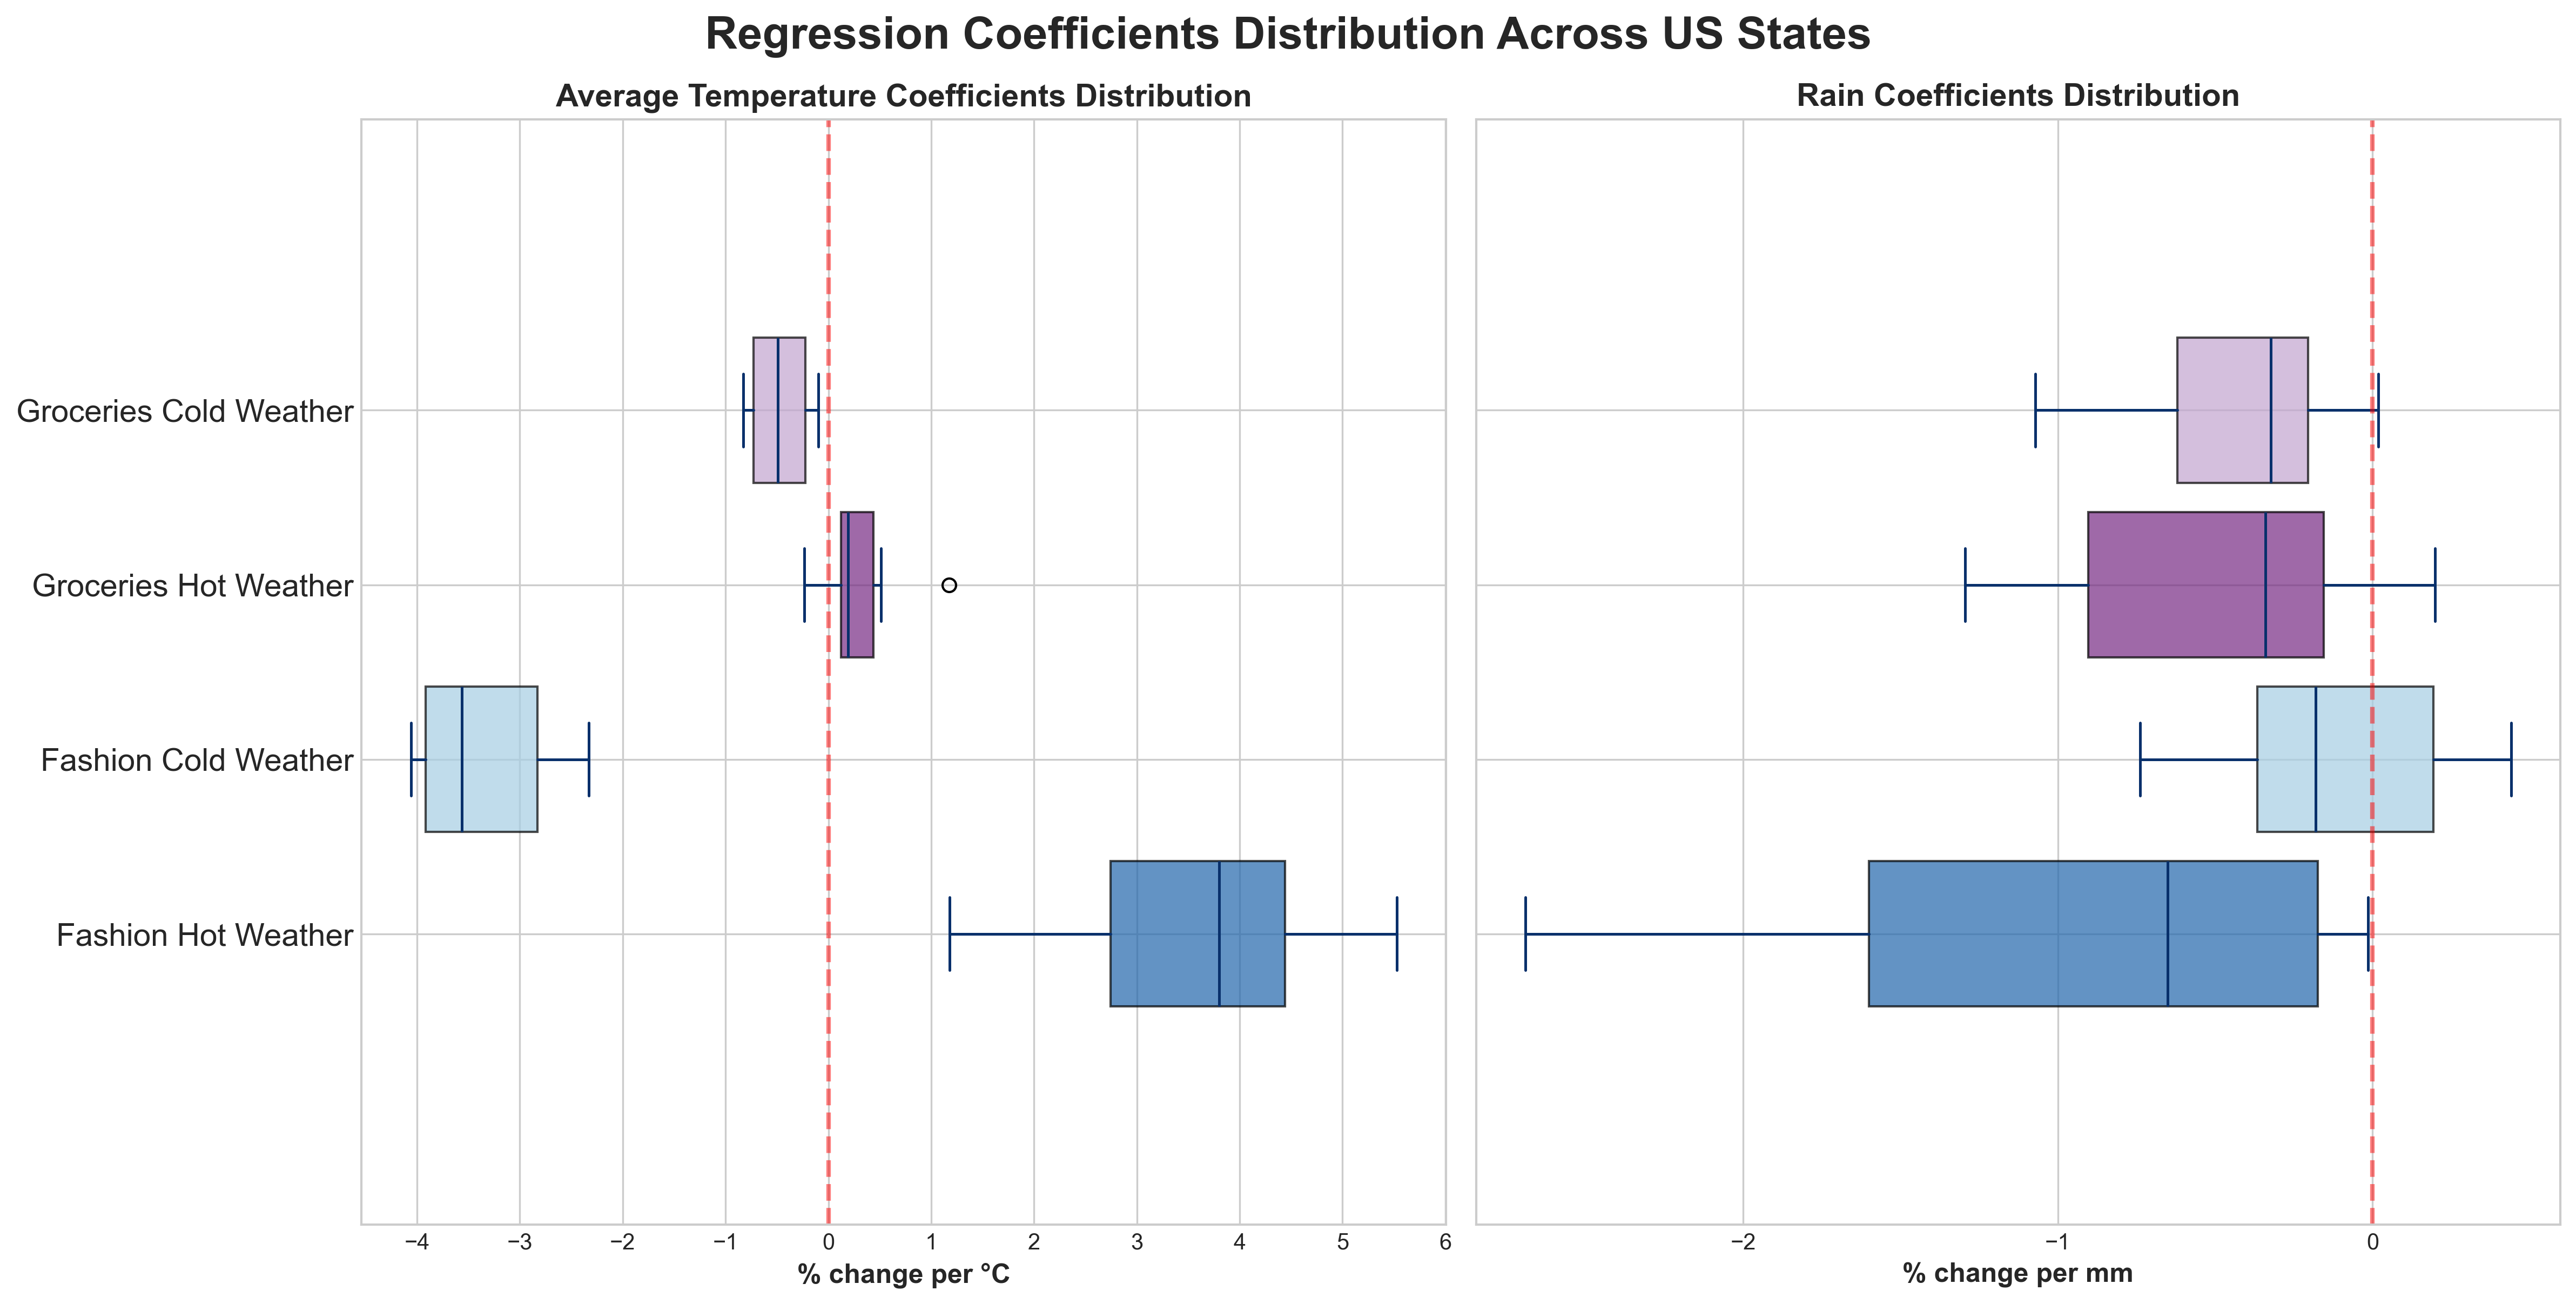

In [184]:
df_list = [fashion_hot_weather_rev, fashion_cold_weather_rev, groceries_hot_weather_rev, groceries_cold_weather_rev]
regression_names = ['Fashion Hot Weather', 'Fashion Cold Weather', 'Groceries Hot Weather', 'Groceries Cold Weather']
fig1 = create_coefficient_boxplots(df_list, regression_names)

In [185]:
def create_pvalue_distributions(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    """
    Create density plots for p-value distributions of tavg and ppt parameters.
    
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')
    """
    
    # Set up the figure with academic styling
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure with two subplots side by side
    fig, (ax_tavg, ax_ppt) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Define color palette for each regression model (matching coefficient plots)
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    line_styles = ['-', '-', '-.', '--']
    
    # Import required library
    try:
        from scipy.stats import gaussian_kde
        use_kde = True
    except ImportError:
        use_kde = False
    
    x_range = np.linspace(0, 1, 100)
    
    # Plot tavg p-value distributions
    for i, (df, name, color, linestyle) in enumerate(zip(df_list, regression_names, colors, line_styles)):
        p_values_tavg = df['P_value1'].values
        
        if use_kde:
            try:
                kde_tavg = gaussian_kde(p_values_tavg)
                density_tavg = kde_tavg(x_range)
                ax_tavg.plot(x_range, density_tavg, color=color, linewidth=2.5, 
                           alpha=0.8, label=name, linestyle=linestyle)
            except:
                # Fallback to histogram if KDE fails
                ax_tavg.hist(p_values_tavg, bins=20, density=True, alpha=0.4, 
                           color=color, label=name, histtype='step', linewidth=2)
        else:
            ax_tavg.hist(p_values_tavg, bins=20, density=True, alpha=0.4, 
                       color=color, label=name, histtype='step', linewidth=2)
    
    ax_tavg.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
    ax_tavg.set_xlabel('P-values', fontsize=12, fontweight='bold')
    ax_tavg.set_ylabel('Frequency Density', fontsize=12, fontweight='bold')
    ax_tavg.set_title(f'P-value Distribution - Average Temperature', fontsize=14, fontweight='bold')
    ax_tavg.legend(fontsize=10, loc='upper right')
    ax_tavg.grid(True, alpha=0.3)
    ax_tavg.set_xlim(0, 1)
    
    # Plot ppt p-value distributions
    for i, (df, name, color, linestyle) in enumerate(zip(df_list, regression_names, colors, line_styles)):
        p_values_ppt = df['P_value2'].values
        
        if use_kde:
            try:
                kde_ppt = gaussian_kde(p_values_ppt)
                density_ppt = kde_ppt(x_range)
                ax_ppt.plot(x_range, density_ppt, color=color, linewidth=2.5, 
                          alpha=0.8, label=name, linestyle=linestyle)
            except:
                # Fallback to histogram if KDE fails
                ax_ppt.hist(p_values_ppt, bins=20, density=True, alpha=0.4, 
                          color=color, label=name, histtype='step', linewidth=2)
        else:
            ax_ppt.hist(p_values_ppt, bins=20, density=True, alpha=0.4, 
                      color=color, label=name, histtype='step', linewidth=2)
    
    ax_ppt.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
    ax_ppt.set_xlabel('P-values', fontsize=12, fontweight='bold')
    ax_ppt.set_ylabel('Frequency Density', fontsize=12, fontweight='bold')
    ax_ppt.set_title(f'P-value Distribution - Precipitation', fontsize=14, fontweight='bold')
    ax_ppt.legend(fontsize=10, loc='upper right')
    ax_ppt.grid(True, alpha=0.3)
    ax_ppt.set_xlim(0, 1)
    
    # Add overall title
    fig.suptitle('P-value Distributions Across Regression Models', 
                fontsize=16, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.savefig('./Exports/regression_p_values.png', dpi=300, bbox_inches='tight')
    
    return fig

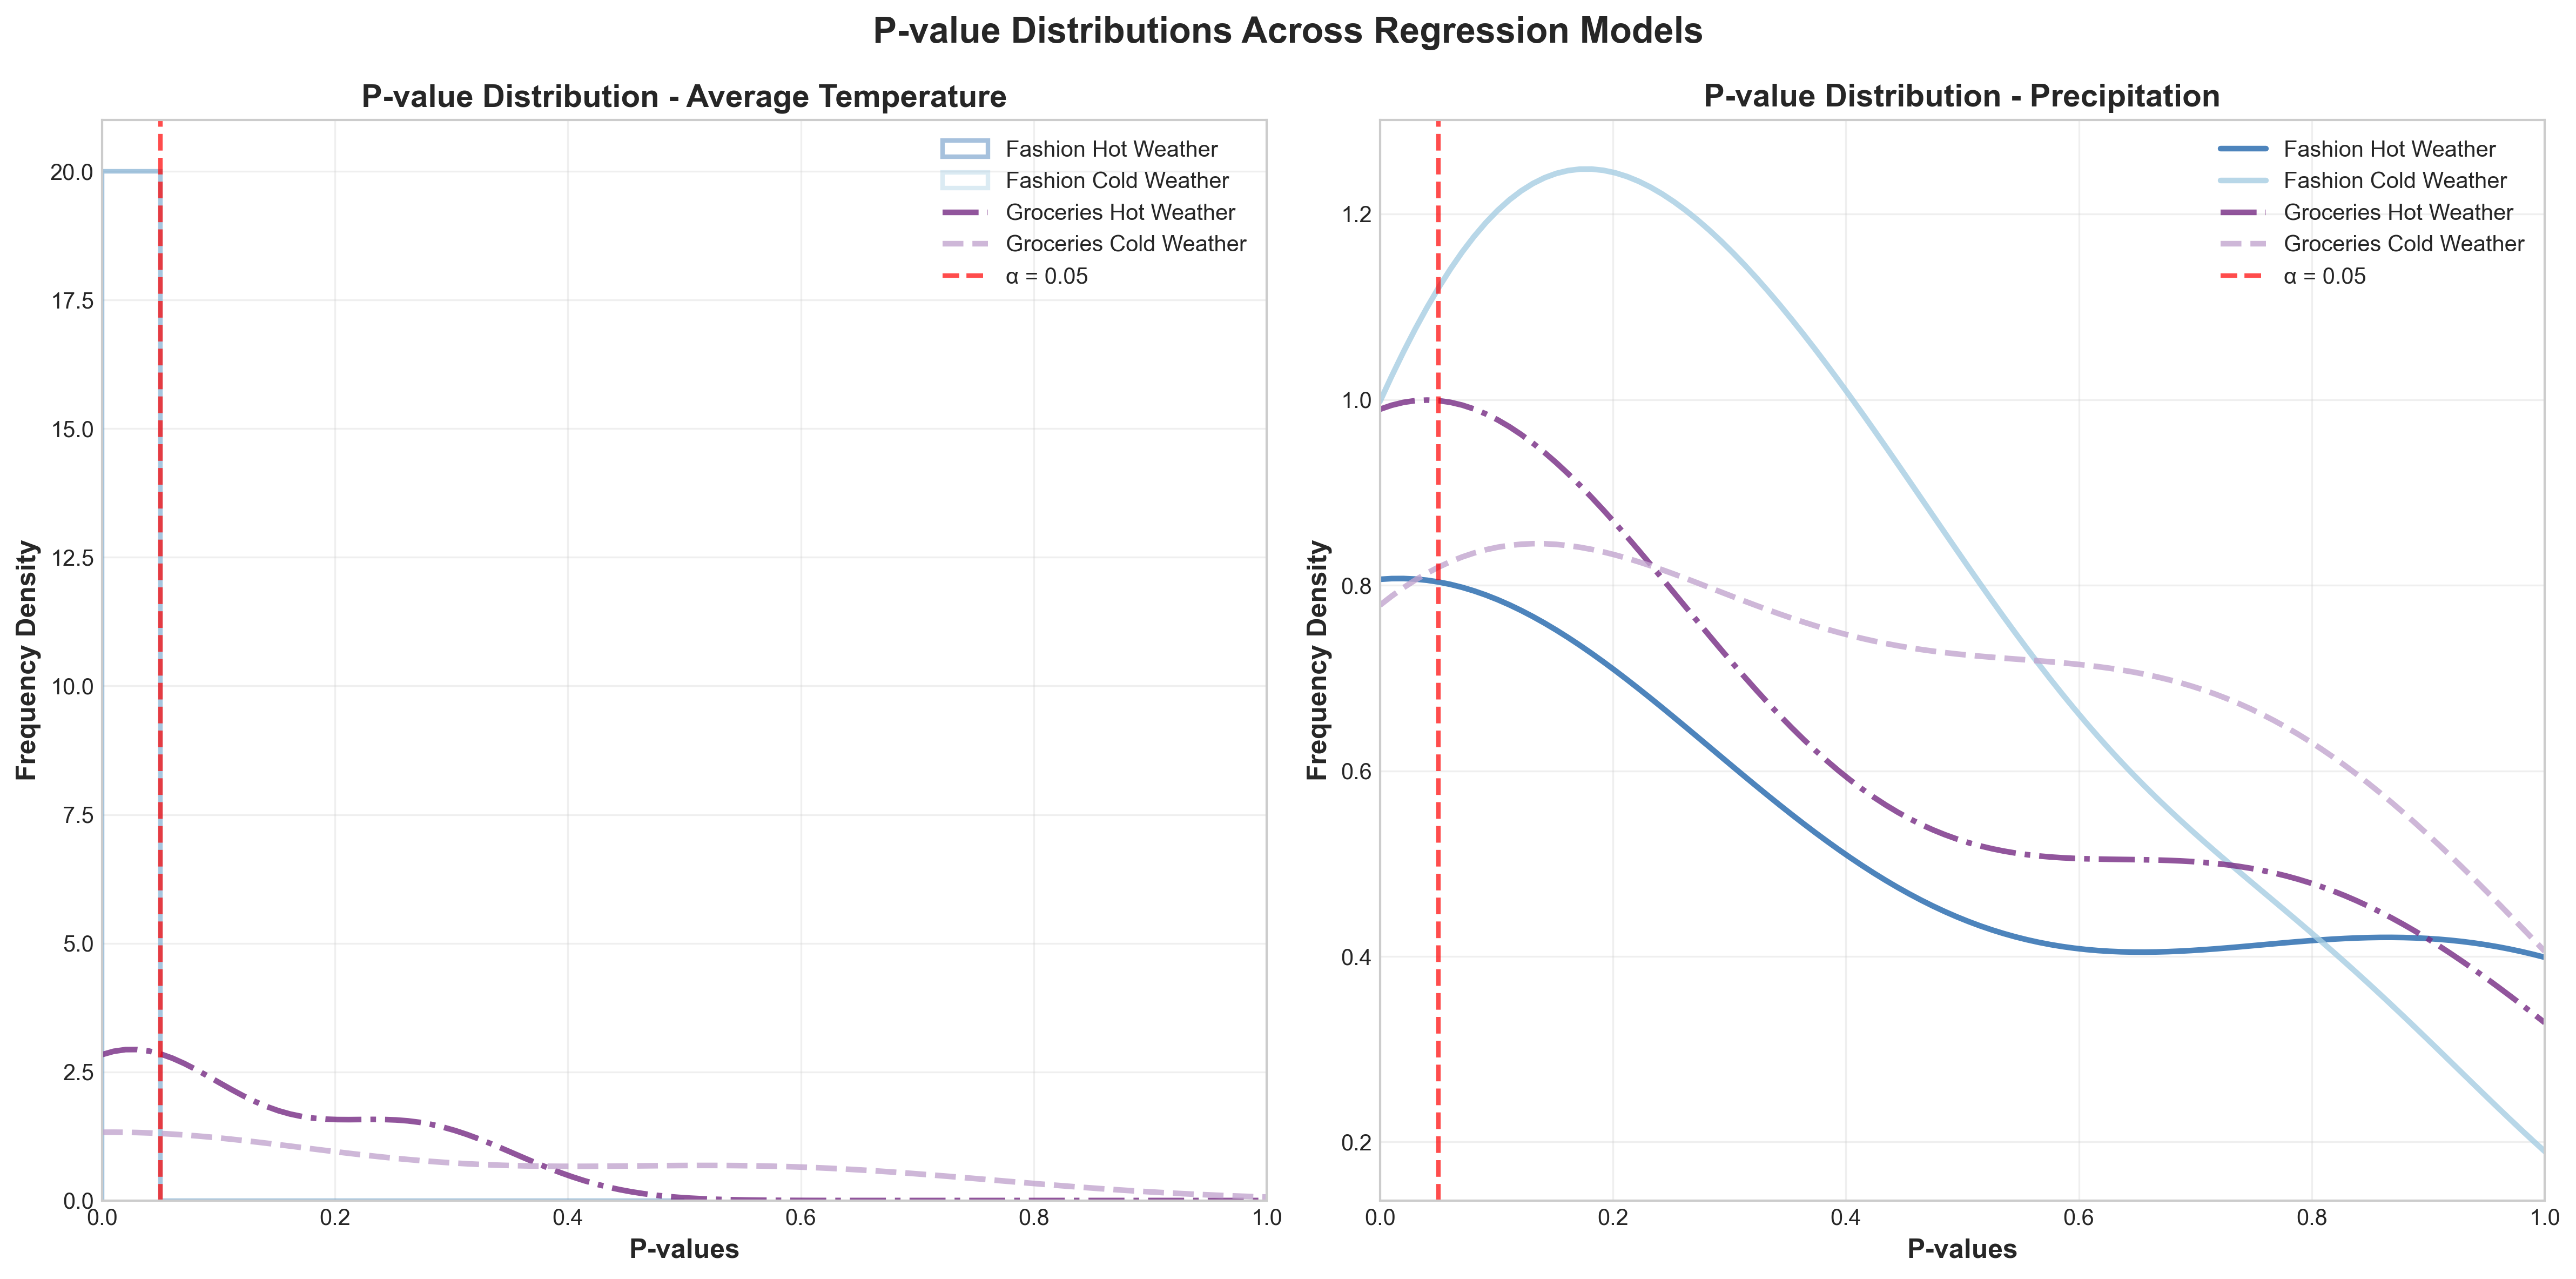

In [186]:
fig2 = create_pvalue_distributions(df_list, regression_names) 